# Lipkin–Meshkov–Glick Model Coupled to a Cavity
## Photon Number Fluctuations and Spin Noise Spectral Density

### Physical Model

The Hamiltonian couples $N$ collective spins (LMG model) to a single cavity
mode via an $S_z$ interaction, with a periodic transverse-field drive:

$$H(t) = -\frac{J}{N}S_z^2 + h_0\cos(\Omega t)\,S_x
+ \omega_0\,a^\dagger a + \frac{2g}{\sqrt{N}}(a+a^\dagger)\,S_z$$

**Heisenberg EOM for the cavity** (from $\dot{a}=-i[a,H]$):

$$\dot{a} = -i\omega_0\,a - i\frac{2g}{\sqrt{N}}\,S_z(t)$$

The cavity is driven entirely by spin noise $S_z(t)$.  
Whether it thermalises depends on the **spin noise spectral density** at $\omega_0$:

$$S_{zz}(\omega)\approx\left|\mathcal{F}[\langle S_z(t)\rangle]\right|^2$$

| Spin-bath regime | $S_{zz}(\omega)$ shape | Cavity outcome |
|---|---|---|
| Ergodic / chaotic  | broad, featureless | thermalises efficiently |
| Integrable / regular | sharp peaks only | stays near vacuum |

The driven LMG bath enters the **chaotic regime** when $h_0\gtrsim J$
and $\Omega\sim J$ (near-resonant, strong drive).

In [1]:
from qutip import *
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({'figure.dpi': 100, 'font.size': 12})

In [2]:
def build_ops(N, N_ph, J, omega_0, g):
    """Build operators for the LMG-cavity system.

    Static Hamiltonian:
        H_static = -(J/N) Sz^2  +  omega_0 * a†a  +  (2g/sqrt(N)) * (a+a†) * Sz

    Drive term  h0*cos(Omega*t)*Sx  is added as a time-dependent term.

    Returns
    -------
    H_static, H_drive, n_ph_op, Sz_op, psi0
    """
    S        = N / 2.0
    dim_spin = int(2 * S + 1)

    # Collective spin operators
    Sx     = jmat(S, 'x')
    Sz     = jmat(S, 'z')
    I_spin = qeye(dim_spin)

    # Cavity operators
    a    = destroy(N_ph)
    I_ph = qeye(N_ph)

    # Promote to full Hilbert space  spin ⊗ photon
    Sx_full   = tensor(Sx, I_ph)
    Sz_full   = tensor(Sz, I_ph)
    n_ph_full = tensor(I_spin, a.dag() * a)
    X_ph_full = tensor(I_spin, a + a.dag())    # cavity quadrature

    # Hamiltonian parts
    H_lmg    = -(J / N) * tensor(Sz * Sz, I_ph)              # LMG interaction
    H_cav    = omega_0 * n_ph_full                            # cavity energy
    H_int    = (2.0 * g / np.sqrt(N)) * X_ph_full * Sz_full  # Sz coupling

    H_static = H_lmg + H_cav + H_int
    H_drive  = Sx_full                          # transverse drive operator

    # Initial state: max-Sx eigenstate  x  photon vacuum
    evals, evecs = Sx.eigenstates()
    psi0 = tensor(evecs[np.argmax(evals)], basis(N_ph, 0))

    return H_static, H_drive, n_ph_full, Sz_full, psi0

In [15]:
from scipy.special import jn_zeros
# =====================================================================
# CONTROLLABLE PARAMETERS — modify these freely
# =====================================================================
N    = 8       # number of spins  (collective spin S = N/2)
N_ph = 15      # photon Fock-space cutoff  (raise if <n> → N_ph)

J    = 1.0     # LMG coupling  (sets the energy scale)

# --- Drive: CHAOTIC regime when h0 > J and Omega ~ J ---
Omega = 0.7    # drive frequency   (chaotic: near-resonant with spin gap)
h0    = jn_zeros(0,5)[1] * Omega/4    # drive amplitude   (chaotic: h0 / J ~ 2-3)

# --- Cavity ---
omega_0 = 1.0  # cavity frequency
g       = 0.10 # spin-cavity coupling  (probe limit: g << J)

# --- Time grid ---
T_total = 3000.0  # total evolution time  [units of 1/J]
dt      = 0.05   # time step
# =====================================================================

In [16]:
def drive_coeff(t, args):
    return args['h0'] * np.cos(args['Omega'] * t)

tlist = np.linspace(0, T_total, int(T_total / dt) + 1)
args  = {'h0': h0, 'Omega': Omega}

H_static, H_drive, n_ph_op, Sz_op, psi0 = build_ops(N, N_ph, J, omega_0, g)
H_td = [H_static, [H_drive, drive_coeff]]

print(f'Hilbert space : {H_static.shape[0]}  ({N+1} spin x {N_ph} photon)')
print(f'Time steps    : {len(tlist)}')
print(f'Drive         : h0={h0}, Omega={Omega}  (h0/J = {h0/J:.1f})')
print('Running sesolve …')

result = mesolve(H_td, psi0, tlist, [], [n_ph_op, Sz_op], args=args)

n_t  = np.array(result.expect[0])   # <a†a>(t)
Sz_t = np.array(result.expect[1])   # <Sz>(t)

if n_t.max() > 0.8 * N_ph:
    print(f'WARNING: max <n> = {n_t.max():.2f} approaches N_ph={N_ph}. Increase N_ph.')
print(f'Done.  max <n> = {n_t.max():.3f},  mean <n> = {n_t.mean():.4f}')

Hilbert space : 135  (9 spin x 15 photon)
Time steps    : 60001
Drive         : h0=0.9660136693001042, Omega=0.7  (h0/J = 1.0)
Running sesolve …
Done.  max <n> = 1.109,  mean <n> = 0.6401


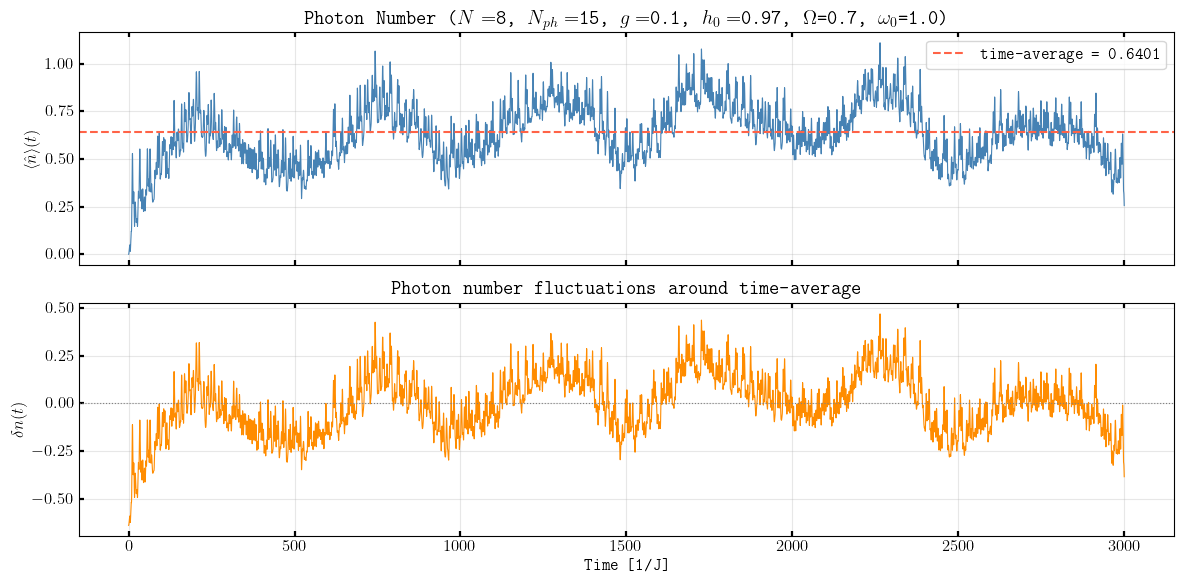

RMS photon fluctuation std(n) = 0.1528


In [18]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(tlist, n_t, lw=0.8, color='steelblue')
ax1.axhline(n_t.mean(), color='tomato', lw=1.5, ls='--',
            label=f'time-average = {n_t.mean():.4f}')
ax1.set_ylabel(r'$\langle \hat{n}\rangle(t)$')
ax1.set_title(
    rf'Photon Number  ($N=${N}, $N_{{ph}}=${N_ph}, $g=${g}, $h_0=${h0:1.2f}, $\Omega$={Omega}, $\omega_0$={omega_0})')
ax1.legend()
ax1.grid(alpha=0.3)

delta_n = n_t - n_t.mean()
ax2.plot(tlist, delta_n, lw=0.8, color='darkorange')
ax2.axhline(0, color='gray', lw=0.8, ls=':')
ax2.set_xlabel('Time  [1/J]')
ax2.set_ylabel(r'$\delta n(t)$')
ax2.set_title('Photon number fluctuations around time-average')
ax2.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig('photon_fluctuations.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'RMS photon fluctuation std(n) = {n_t.std():.4f}')

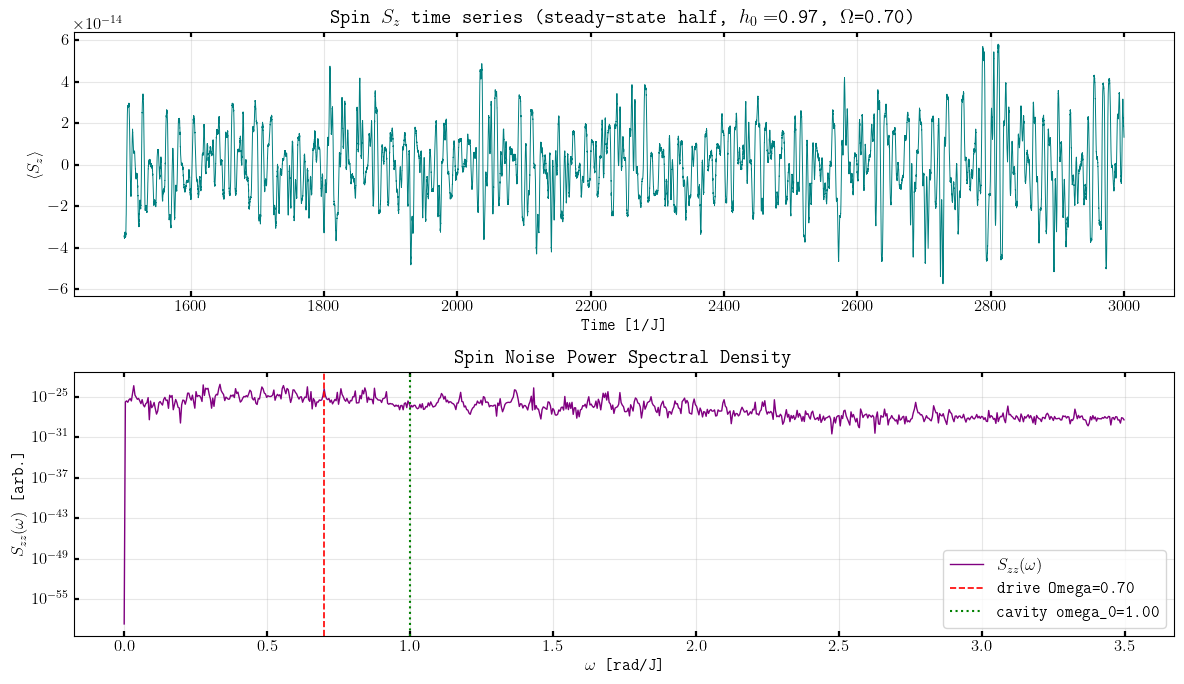

Spectral weight at cavity freq omega_0=1.0:  S_zz = 2.154e-27


In [19]:
# Discard first half (transient); analyse steady-state portion
half   = len(tlist) // 2
Sz_ss  = Sz_t[half:]
Sz_ac  = Sz_ss - Sz_ss.mean()              # remove DC
N_fft  = len(Sz_ac)
freqs  = np.fft.rfftfreq(N_fft, d=dt)
omegas = 2 * np.pi * freqs
S_zz   = np.abs(np.fft.rfft(Sz_ac))**2 / (N_fft * dt)   # one-sided PSD

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7))

ax1.plot(tlist[half:], Sz_ss, lw=0.7, color='teal')
ax1.set_xlabel('Time  [1/J]')
ax1.set_ylabel(r'$\langle S_z\rangle$')
ax1.set_title(rf'Spin $S_z$ time series (steady-state half,  $h_0=${h0:1.2f}, $\Omega$={Omega:1.2f})')
ax1.grid(alpha=0.3)

mask = omegas <= 5 * Omega
ax2.semilogy(omegas[mask], S_zz[mask], lw=1.0, color='purple',
             label=r'$S_{zz}(\omega)$')
ax2.axvline(Omega,   color='red',   ls='--', lw=1.2,
            label=f'drive  Omega={Omega:1.2f}')
ax2.axvline(omega_0, color='green', ls=':',  lw=1.5,
            label=f'cavity omega_0={omega_0:1.2f}')
ax2.set_xlabel(r'$\omega$  [rad/J]')
ax2.set_ylabel(r'$S_{zz}(\omega)$  [arb.]')
ax2.set_title('Spin Noise Power Spectral Density')
ax2.legend()
ax2.grid(alpha=0.3, which='both')

plt.tight_layout()
#plt.savefig('spin_spectral_density.png', dpi=100, bbox_inches='tight')
plt.show()

idx_cav = np.argmin(np.abs(omegas - omega_0))
print(f'Spectral weight at cavity freq omega_0={omega_0}:  S_zz = {S_zz[idx_cav]:.3e}')

## Comparison: Chaotic vs Integrable Spin Bath

With identical cavity/coupling parameters, we contrast two drive regimes:

- **Chaotic**: weak drive $\Omega \approx 0.7$.
- **Localized**: strong drive $\Omega \approx 200$.

In both cases, $h_0$ is chosen such that $J_0(4h/\omega)=0$.

The chaotic bath should produce a **broad** $S_{zz}(\omega)$, meaning significant
spectral weight at all frequencies including $\omega_0$, leading to larger
photon number fluctuations.  
The localized bath produces **sharp harmonic peaks** and the cavity is
barely excited (small $\sigma_n$).

Simulations:   0%|          | 0/2 [00:00<?, ?it/s]

Chaotic                                     S_zz(omega_0)=5.928e-26  max<n>=5.9682  std(n)=0.8465
Localized                                   S_zz(omega_0)=2.386e-24  max<n>=1.0065  std(n)=0.4016


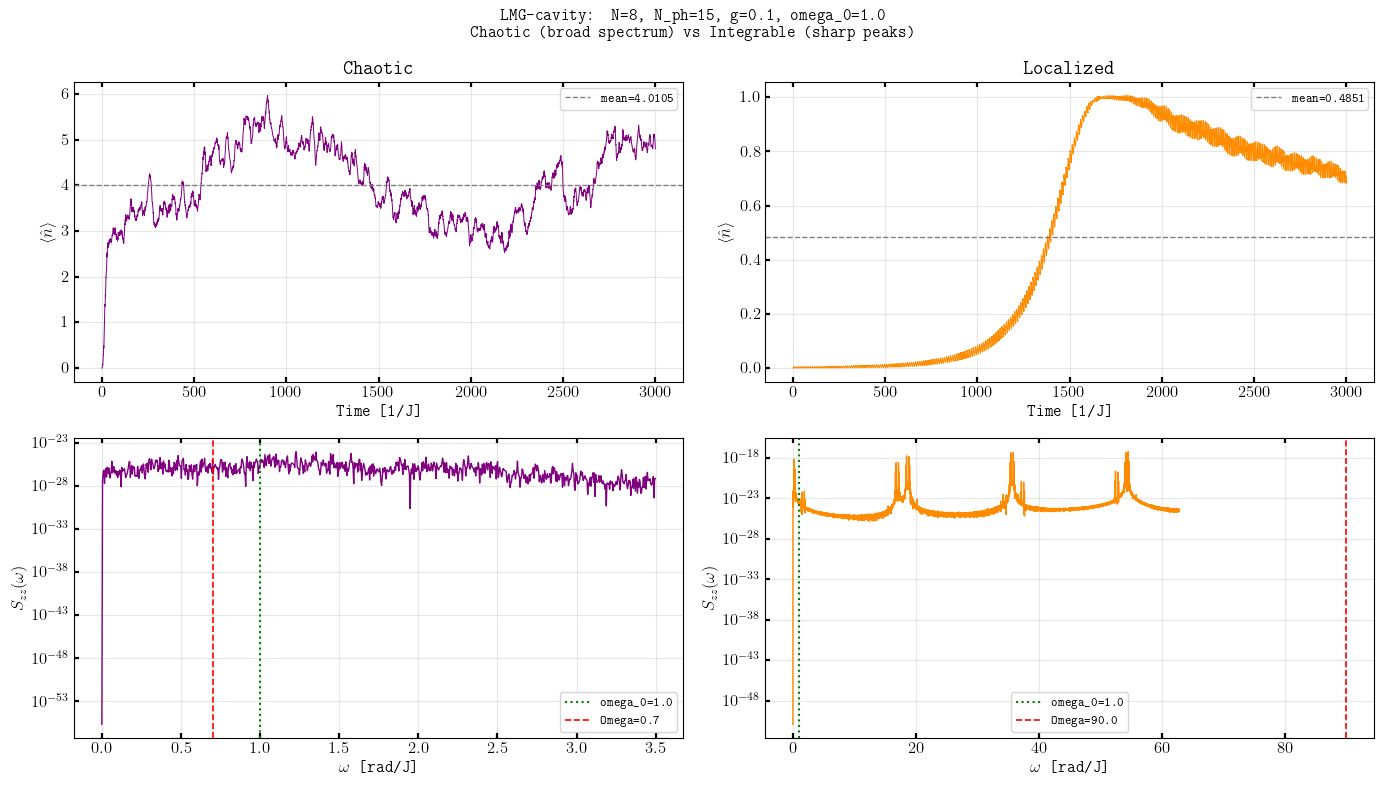

In [21]:
from tqdm.notebook import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing

Omega_therm = 0.7
Omega_loc = 90.0
param_sets = [
    dict(Omega=Omega_therm, h0 = jn_zeros(0,5)[1] * Omega_therm/2, label='Chaotic  ', color='purple'),
    dict(Omega=Omega_loc, h0 = jn_zeros(0,5)[1] * Omega_loc/2, label='Localized', color='darkorange'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

def run_simulation(p, N, N_ph, J, omega_0, g, tlist, dt):
    """Run a single mesolve simulation for a given parameter set."""
    H_static_i, H_drive_i, n_ph_op_i, Sz_op_i, psi0_i = build_ops(N, N_ph, J, omega_0, g)
    res = mesolve(
        [H_static_i, [H_drive_i, drive_coeff]],
        psi0_i, tlist, [],
        [n_ph_op_i, Sz_op_i],
        args={'h0': p['h0'], 'Omega': p['Omega']}
    )
    n_i  = np.array(res.expect[0])
    Sz_i = np.array(res.expect[1])
    half_i   = len(tlist) // 2
    Sz_ac_i  = Sz_i[half_i:] - Sz_i[half_i:].mean()
    N_fi     = len(Sz_ac_i)
    omegas_i = 2 * np.pi * np.fft.rfftfreq(N_fi, d=dt)
    S_zz_i   = np.abs(np.fft.rfft(Sz_ac_i))**2 / (N_fi * dt)
    return dict(n_i=n_i, Sz_i=Sz_i, omegas_i=omegas_i, S_zz_i=S_zz_i, p=p)

results_list = [None] * len(param_sets)

with tqdm(total=len(param_sets), desc='Simulations') as pbar:
    with ProcessPoolExecutor(max_workers=min(len(param_sets), multiprocessing.cpu_count())) as executor:
        futures = {
            executor.submit(run_simulation, p, N, N_ph, J, omega_0, g, tlist, dt): col
            for col, p in enumerate(param_sets)
        }
        for future in as_completed(futures):
            col = futures[future]
            results_list[col] = future.result()
            pbar.update(1)

for col, data in enumerate(results_list):
    p        = data['p']
    n_i      = data['n_i']
    omegas_i = data['omegas_i']
    S_zz_i   = data['S_zz_i']
    mask_i   = omegas_i <= 5 * p['Omega']

    axes[0, col].plot(tlist, n_i, lw=0.7, color=p['color'])
    axes[0, col].axhline(n_i.mean(), color='gray', ls='--', lw=1.0,
                         label=f'mean={n_i.mean():.4f}')
    axes[0, col].set_title(p['label'])
    axes[0, col].set_xlabel('Time [1/J]')
    axes[0, col].set_ylabel(r'$\langle\hat{n}\rangle$')
    axes[0, col].legend(fontsize=9)
    axes[0, col].grid(alpha=0.3)

    axes[1, col].semilogy(omegas_i[mask_i], S_zz_i[mask_i],
                          lw=1.0, color=p['color'])
    axes[1, col].axvline(omega_0,    color='green', ls=':',  lw=1.5,
                         label=f'omega_0={omega_0}')
    axes[1, col].axvline(p['Omega'], color='red',   ls='--', lw=1.2,
                         label=f"Omega={p['Omega']}")
    axes[1, col].set_xlabel(r'$\omega$  [rad/J]')
    axes[1, col].set_ylabel(r'$S_{zz}(\omega)$')
    axes[1, col].legend(fontsize=9)
    axes[1, col].grid(alpha=0.3, which='both')

    idx   = np.argmin(np.abs(omegas_i - omega_0))
    sig_n = n_i.std()
    print(f'{p["label"]:42s}  S_zz(omega_0)={S_zz_i[idx]:.3e}  '
          f'max<n>={n_i.max():.4f}  std(n)={sig_n:.4f}')

fig.suptitle(
    f'LMG-cavity: N={N}, N_ph={N_ph}, g={g}, omega_0={omega_0}\n'
    'Chaotic (broad spectrum) vs Integrable (sharp peaks)',
    fontsize=12
)
plt.tight_layout()
plt.show()

### Self-contained sweep

This cell sweeps spin sizes from $N=10$ to $200$, keeps the cavity cutoff fixed, and uses a multiprocessing pool to compute only the temporal standard deviation of the cavity population, $\mathrm{std}[n(t)]$, in the chaotic drive regime.

In [ ]:
import multiprocessing
import os

import numpy as np
from qutip import basis, destroy, jmat, mesolve, qeye, tensor
from scipy.special import jn_zeros
from tqdm.auto import tqdm


# ---------------------------------------------------------------------
# Self-contained helpers
# ---------------------------------------------------------------------
def build_ops(N, N_ph, J, omega_0, g):
    """Build operators for the LMG-cavity system."""
    S = N / 2.0
    dim_spin = int(2 * S + 1)

    Sx = jmat(S, 'x')
    Sz = jmat(S, 'z')
    I_spin = qeye(dim_spin)

    a = destroy(N_ph)
    I_ph = qeye(N_ph)

    Sx_full = tensor(Sx, I_ph)
    Sz_full = tensor(Sz, I_ph)
    n_ph_full = tensor(I_spin, a.dag() * a)
    X_ph_full = tensor(I_spin, a + a.dag())

    H_lmg = -(J / N) * tensor(Sz * Sz, I_ph)
    H_cav = omega_0 * n_ph_full
    H_int = (2.0 * g / np.sqrt(N)) * X_ph_full * Sz_full

    H_static = H_lmg + H_cav + H_int
    H_drive = Sx_full

    evals, evecs = Sx.eigenstates()
    psi0 = tensor(evecs[np.argmax(evals)], basis(N_ph, 0))

    return H_static, H_drive, n_ph_full, psi0


def drive_coeff(t, args):
    return args['h0'] * np.cos(args['Omega'] * t)


def cavity_population_std(task):
    """Run mesolve for one spin size and return std[n(t)]."""
    N_spin, N_ph, J, omega_0, g, h0, Omega, T_total, dt = task
    tlist_sweep = np.linspace(0, T_total, int(T_total / dt) + 1)

    H_static_i, H_drive_i, n_ph_op_i, psi0_i = build_ops(N_spin, N_ph, J, omega_0, g)
    res = mesolve(
        [H_static_i, [H_drive_i, drive_coeff]],
        psi0_i,
        tlist_sweep,
        [],
        [n_ph_op_i],
        args={'h0': h0, 'Omega': Omega},
    )

    n_t = np.asarray(res.expect[0])
    return N_spin, n_t.std()


# ---------------------------------------------------------------------
# Sweep settings: chaotic regime, fixed cavity truncation
# ---------------------------------------------------------------------
N_spin = 400
J = 1.0
omega_0 = 1.0
g = 0.10
T_total = 3000.0
dt = 0.05

# Keep the cavity-driving parameters in the chaotic regime.
Omega_sweep = 0.7
h0_sweep = jn_zeros(0, 5)[1] * Omega_sweep / 2

N_values = np.arange(2, 201, 12)
tasks = [
    (N_spin, N_ph, J, omega_0, g, h0_sweep, Omega_sweep, T_total, dt)
    for N_ph in N_values
]

# Use multiprocessing Pool to parallelize the sweep.
# Check PBS_NCPUS environment variable for HPC; otherwise use local CPU count
n_cpus = int(os.environ.get('PBS_NCPUS', multiprocessing.cpu_count()))
ctx = multiprocessing.get_context('fork')
with ctx.Pool(processes=min(len(tasks), n_cpus)) as pool:
    std_results = list(
        tqdm(
            pool.imap_unordered(cavity_population_std, tasks),
            total=len(tasks),
            desc='Sweeping N',
        )
    )

std_results.sort(key=lambda item: item[0])
N_out = np.array([item[0] for item in std_results])
std_n = np.array([item[1] for item in std_results])

checkpoint_file = 'cavity_population_sweep_checkpoint.npz'
np.savez_compressed(
    checkpoint_file,
    N_out=N_out,
    std_n=std_n,
    N_spin=N_spin,
    J=J,
    omega_0=omega_0,
    g=g,
    Omega_sweep=Omega_sweep,
    h0_sweep=h0_sweep,
    T_total=T_total,
    dt=dt,
)

print(f'Saved sweep checkpoint to {checkpoint_file}')
print(f'Used {n_cpus} CPU(s) for parallel sweep')


Uncertainties (1-sigma): a_err=0.002, b_err=0.475
Uncertainties (1-sigma): a_err=0.000, b_err=0.051


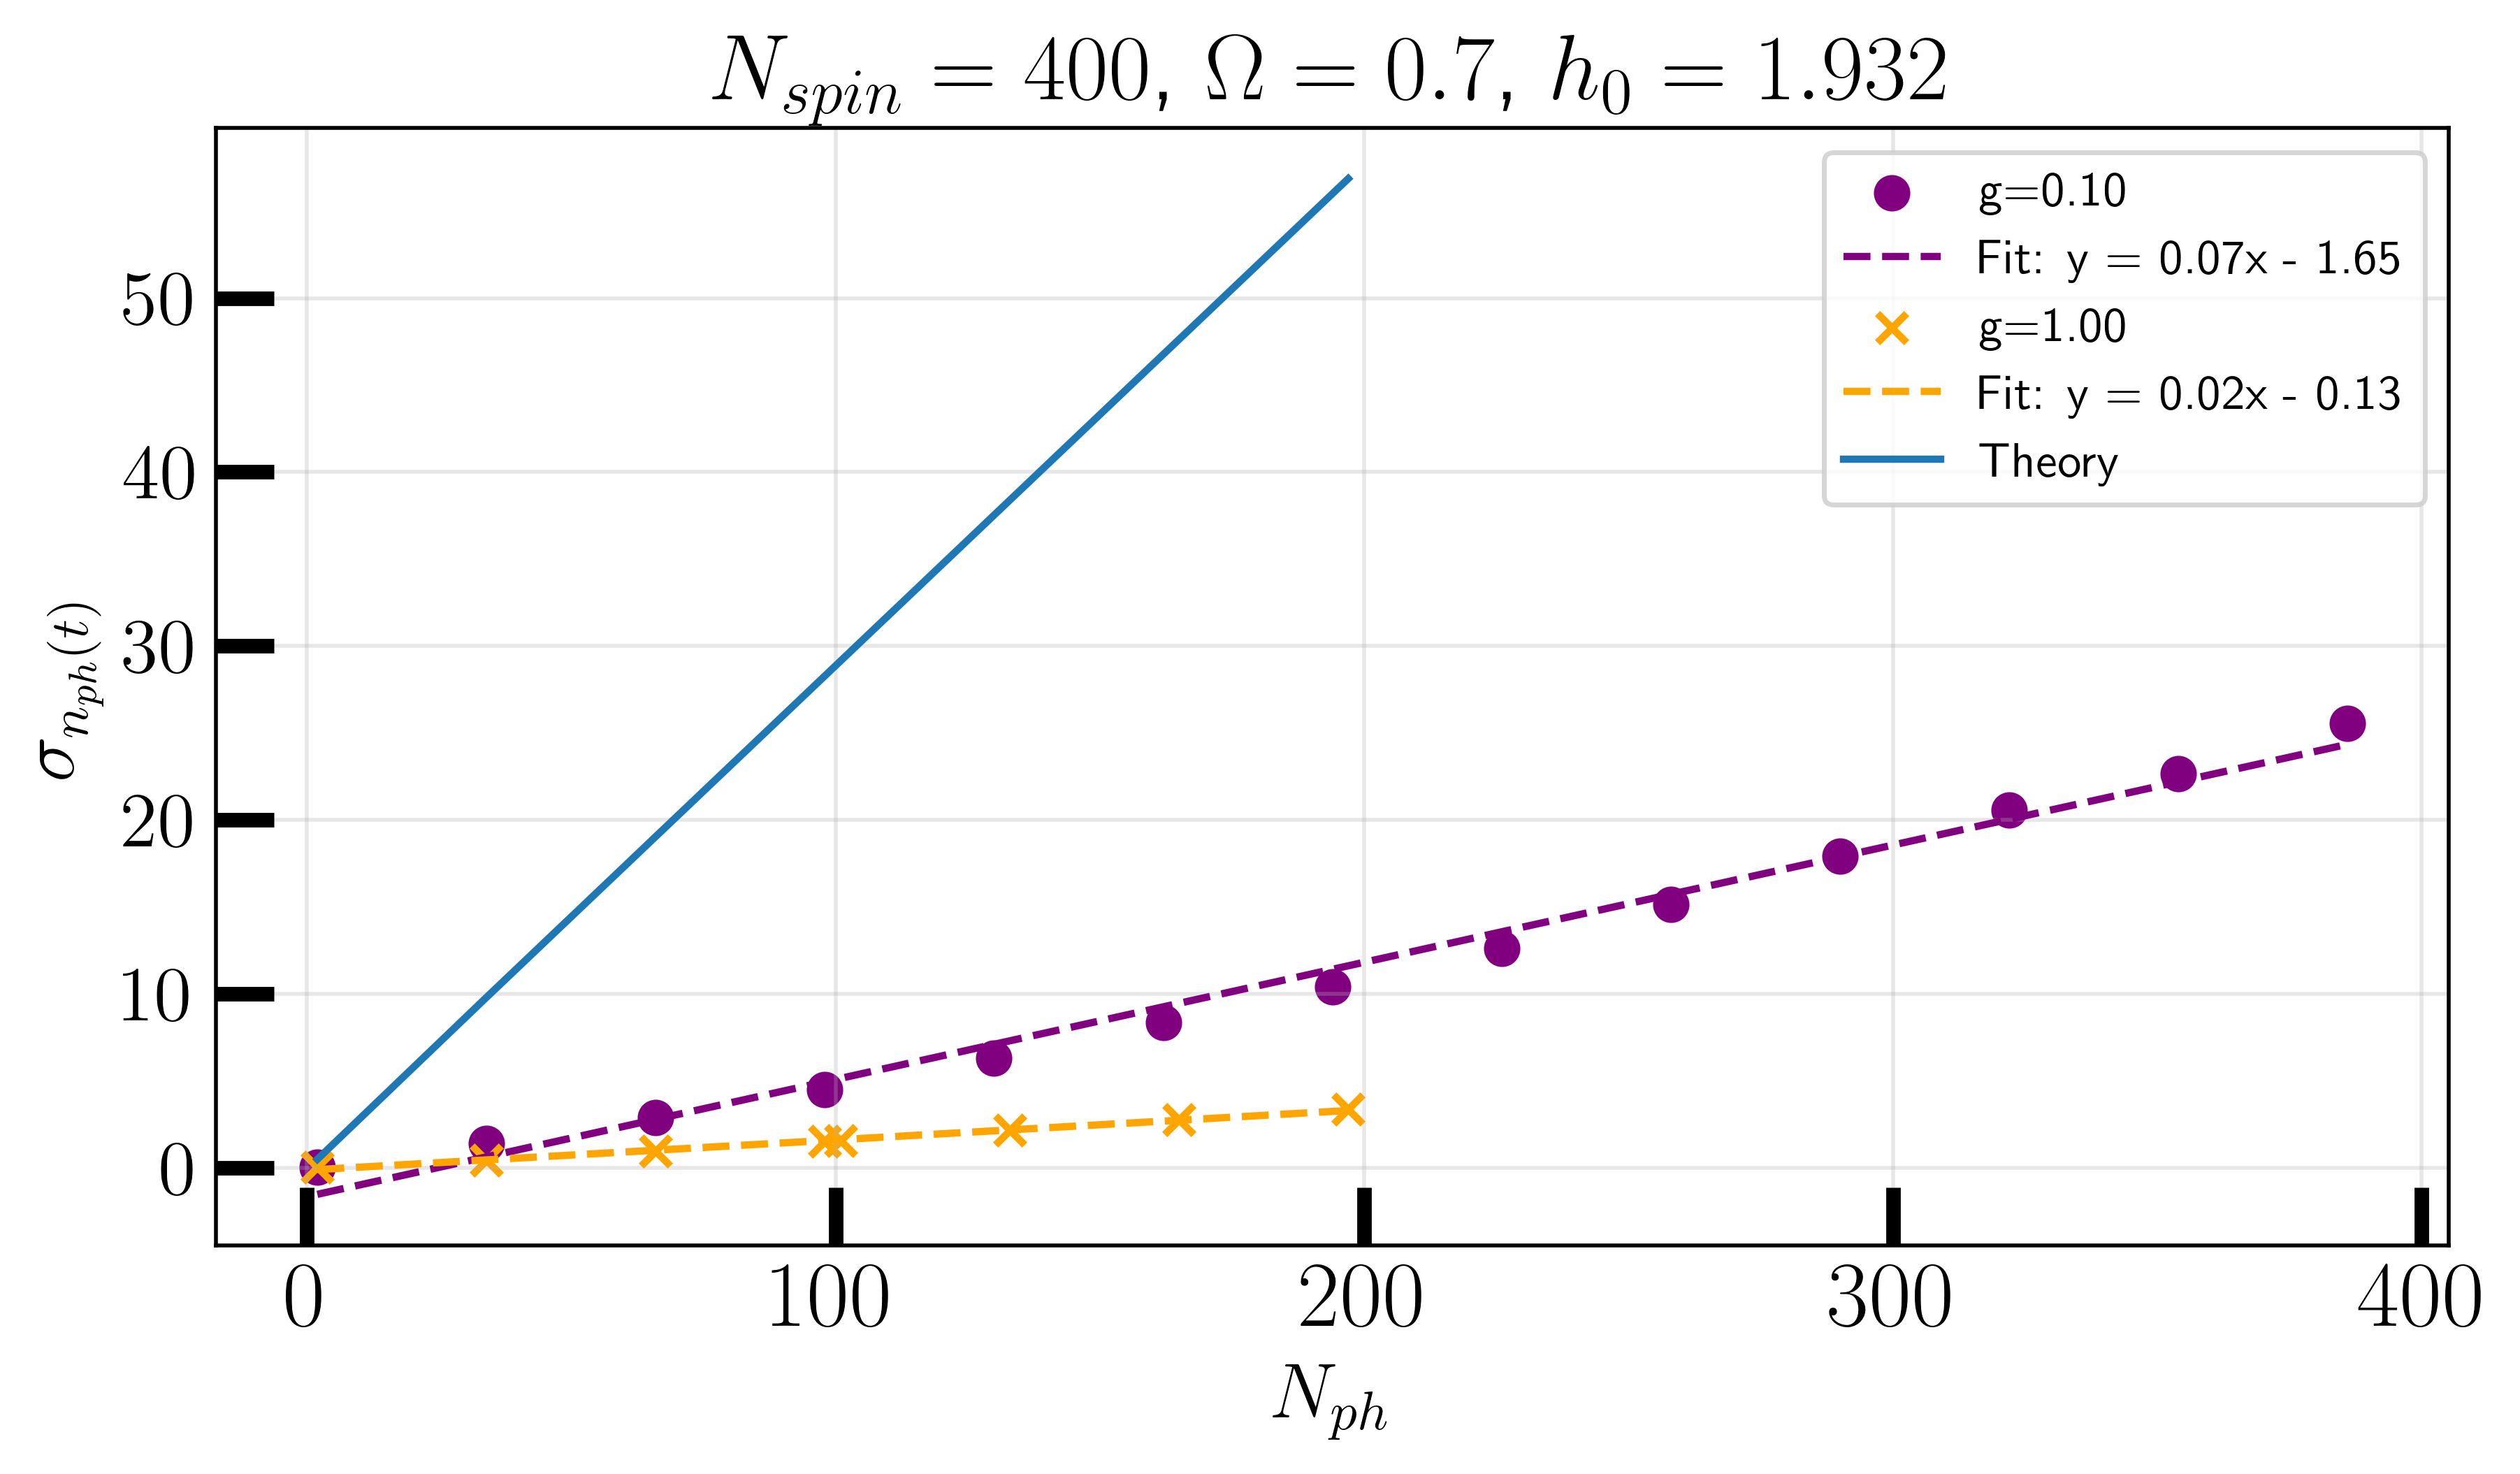

In [11]:
import os

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

checkpoint_file_lowg = '../Data/cavity_population_sweep_checkpoint_low_g.npz'

checkpoint_files_highg = ['../Data/cavity_population_sweep_checkpoint_high_g_0.npz', '../Data/cavity_population_sweep_checkpoint_high_g_1.npz']

def linear_func(x, a, b):
    return a * x - b

np.random.seed(42)  # For reproducibility

with np.load(checkpoint_file_lowg) as data:
    N_out = data['N_out']
    std_n = data['std_n']
    N_spin = int(data['N_spin'])
    Omega_sweep = float(data['Omega_sweep'])
    h0_sweep = float(data['h0_sweep'])
    g = float(data['g'])

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.scatter(N_out, std_n, marker='o', lw=1.5, color='purple', label=f'g={g:1.2f}')

popt, pcov = curve_fit(linear_func, N_out, std_n)
# 4. Extract parameters and calculate their standard errors
a_fit, b_fit = popt
perr = np.sqrt(np.diag(pcov))  # Standard deviation errors
print(f"Uncertainties (1-sigma): a_err={perr[0]:.3f}, b_err={perr[1]:.3f}")
std_fit = linear_func(N_out, *popt)
ax.plot(N_out, std_fit, color='purple', lw=1.5, ls='--', label=fr"Fit: y = {a_fit:.2f}x - {b_fit:.2f}" )

N_out = []
std_n = []
for file in checkpoint_files_highg:
    with np.load(file) as data:
        N_out.append(data['N_out'])
        std_n.append(data['std_n'])
        N_spin = int(data['N_spin'])
        Omega_sweep = float(data['Omega_sweep'])
        h0_sweep = float(data['h0_sweep'])
        g = float(data['g'])

N_out = np.concatenate(N_out)
std_n = np.concatenate(std_n)
ax.scatter(N_out, std_n, marker='x', color='orange', lw=1.5, label=f'g={g:1.2f}')

popt, pcov = curve_fit(linear_func, N_out, std_n)
# 4. Extract parameters and calculate their standard errors
a_fit, b_fit = popt
perr = np.sqrt(np.diag(pcov))  # Standard deviation errors
print(f"Uncertainties (1-sigma): a_err={perr[0]:.3f}, b_err={perr[1]:.3f}")
std_fit = linear_func(N_out, *popt)
ax.plot(N_out, std_fit, color='orange', lw=1.5, ls='--', label=f"Fit: y = {a_fit:.2f}x - {b_fit:.2f}" )

# Theory
ax.plot(N_out, np.sqrt((N_out**2-1)/12), label="Theory")



ax.set_xlabel(r'$N_{ph}$')
ax.set_ylabel(r'$\sigma_{n_{ph}(t)}$')
ax.set_title(
    rf'$N_{{spin}}={N_spin}$, $\Omega={Omega_sweep}$, $h_0={h0_sweep:.3f}$'
)

# The legend needs to be to the right of the frame
ax.legend(loc="upper right", fontsize=10)


ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
